In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
heart = fetch_openml('heart-statlog', version=1, as_frame=True, parser='auto')
X = heart.data



In [3]:
X

,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6


In [4]:
# Chuyển nhãn (1: Khỏe mạnh, 2: Bị bệnh tim) thành nhị phân (0: Khỏe mạnh, 1: Bị bệnh tim)
y = (heart.target == 'present').astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Bài 1: Trực quan Confusion Matrix

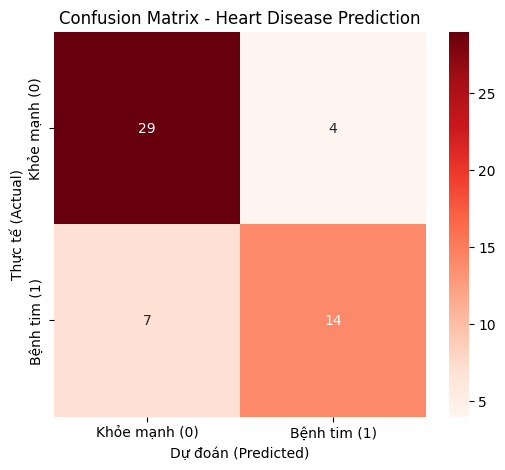

              precision    recall  f1-score   support

   Khỏe mạnh       0.81      0.88      0.84        33
    Bệnh tim       0.78      0.67      0.72        21

    accuracy                           0.80        54
   macro avg       0.79      0.77      0.78        54
weighted avg       0.79      0.80      0.79        54



In [5]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Khỏe mạnh (0)', 'Bệnh tim (1)'], 
            yticklabels=['Khỏe mạnh (0)', 'Bệnh tim (1)'])
plt.title('Confusion Matrix - Heart Disease Prediction')
plt.ylabel('Thực tế (Actual)')
plt.xlabel('Dự đoán (Predicted)')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Khỏe mạnh', 'Bệnh tim']))

### 📊 Bài 2: Phân tích Trọng số Đặc trưng (Feature Importance Analysis)

---

#### 1. Top 3 thuộc tính quan trọng nhất (Most Signficant Features)

| Hạng | Tên Đặc trưng | Ý nghĩa Lâm sàng thực tế | Tác động thuộc tính |
| :---: | :--- | :--- | :--- |
| **01** | `thal` | Kết quả chụp nhấp nháy cơ tim Thallium | Đo lường chính xác lưu lượng máu và mức độ tổn thương mạch vành nuôi tim. |
| **02** | `cp` | Kiểu trạng thái đau thắt ngực (Chest Pain Type) | Biểu hiện triệu chứng cơ năng điển hình của hội chứng tim mạch cấp. |
| **03** | `max_heart_rate` | Tần số nhịp tim tối đa đạt được | Phản ánh giới hạn chịu tải và thể lực tổng quan của hệ tuần hoàn. |



C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3480\2149467337.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Độ quan trọng', y='Thuộc tính', data=feat_df.head(10), palette='magma')


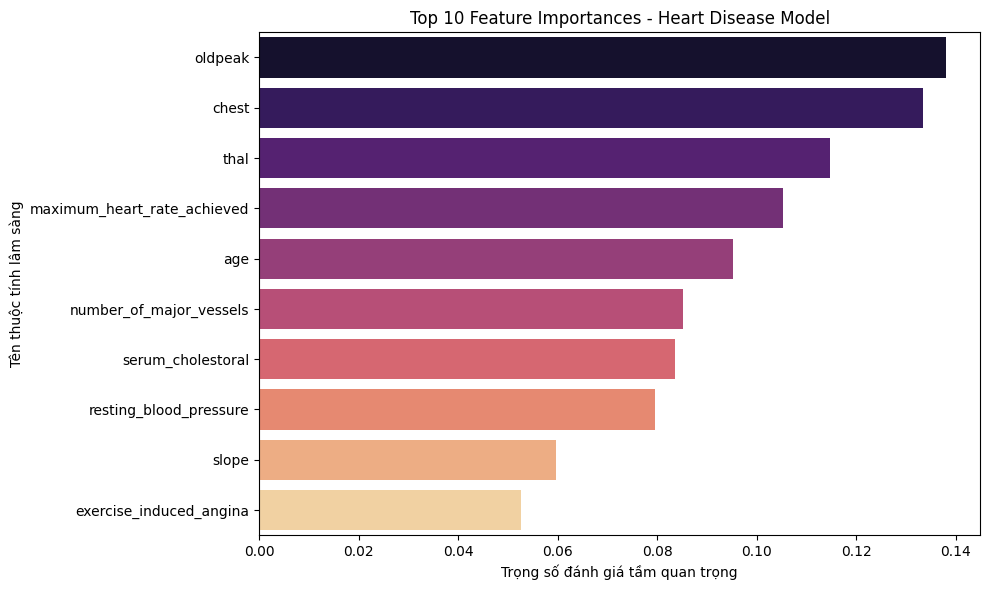

In [6]:
importances = model.feature_importances_

feat_df = pd.DataFrame({'Thuộc tính': X.columns, 'Độ quan trọng': importances})

feat_df = feat_df.sort_values(by='Độ quan trọng', ascending=False).reset_index(drop=True)

# Vẽ đồ thị cột
plt.figure(figsize=(10, 6))
sns.barplot(x='Độ quan trọng', y='Thuộc tính', data=feat_df.head(10), palette='magma')
plt.title('Top 10 Feature Importances - Heart Disease Model')
plt.xlabel('Trọng số đánh giá tầm quan trọng')
plt.ylabel('Tên thuộc tính lâm sàng')
plt.tight_layout()
plt.show()

# Bài 3: SHAP Explainability

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


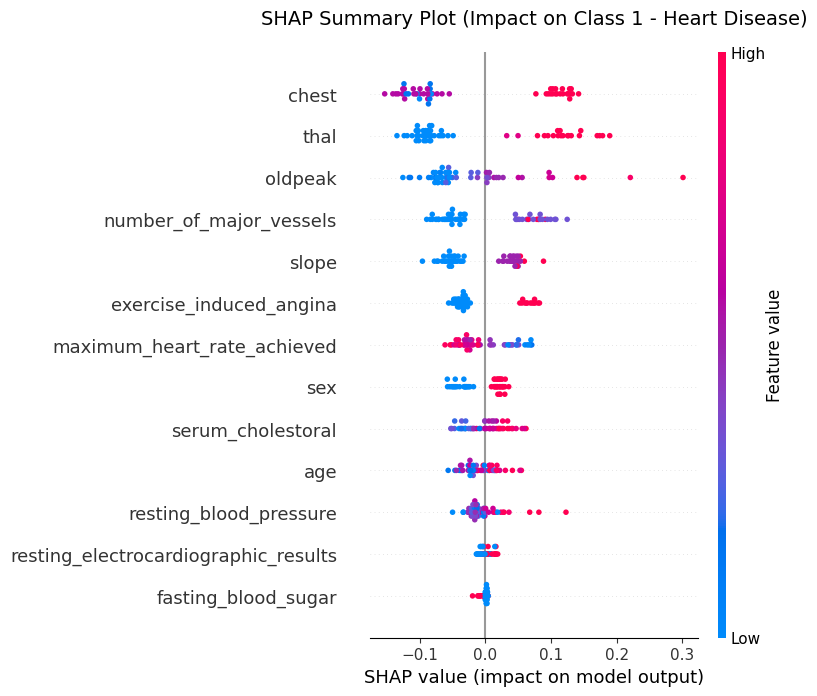

In [7]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Vẽ SHAP Summary Plot cho lớp 1 (Bệnh tim)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values[:, :, 1], X_test, feature_names=X.columns, show=False)
plt.title("SHAP Summary Plot (Impact on Class 1 - Heart Disease)", fontsize=14, pad=20)
plt.show()

# Bài 4: Dashboard giải thích mô hình AI với Streamlit


In [13]:
import os
# 1. Định nghĩa mã nguồn Streamlit 
streamlit_code = """import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

st.set_page_config(page_title="AI Heart Disease Dashboard", layout="wide")
st.title("AI Model Explanation Dashboard (Heart Disease Prediction)")
st.markdown("---")

@st.cache_resource
def load_and_train():
    heart = fetch_openml('heart-statlog', version=1, as_frame=True, parser='auto')
    X = heart.data
    y = (heart.target == 'present').astype(int)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)
    return model, X_test, y_test, X.columns

model, X_test, y_test, feature_names = load_and_train()
y_pred = model.predict(X_test)

col1, col2 = st.columns(2)

with col1:
    st.subheader(" Confusion Matrix (Ma trận nhầm lẫn)")
    cm = confusion_matrix(y_test, y_pred)
    fig1, ax1 = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=['Khỏe mạnh (0)', 'Bệnh tim (1)'],
                yticklabels=['Khỏe mạnh (0)', 'Bệnh tim (1)'], ax=ax1)
    ax1.set_ylabel('Thực tế (Actual)')
    ax1.set_xlabel('Dự đoán (Predicted)')
    plt.tight_layout()
    st.pyplot(fig1)

with col2:
    st.subheader(" Feature Importance (Mức độ quan trọng đặc trưng)")
    importances = model.feature_importances_
    feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feat_df = feat_df.sort_values(by='Importance', ascending=False).head(10)
    fig2, ax2 = plt.subplots(figsize=(6, 4))
    sns.barplot(x='Importance', y='Feature', data=feat_df, palette='magma', ax=ax2)
    ax2.set_xlabel('Trọng số quan trọng')
    ax2.set_ylabel('Chỉ số lâm sàng')
    plt.tight_layout()
    st.pyplot(fig2)
"""

#  tìm ra đường dẫn ngắn gọn: C:\Users\<Tên>\Downloads
download_path = os.path.join(os.path.expanduser("~"), "Downloads", "app_lab8_heart.py")

# 3. Tiến hành ghi file 
with open(download_path, "w", encoding="utf-8") as file:
    file.write(streamlit_code)

print(f"File:\n {download_path}")

File:
 C:\Users\LENOVO\Downloads\app_lab8_heart.py


In [ ]:
#cd Downloads
#python -m streamlit run app_lab8_heart.py